C:\Users\Bella\AppData\Local\Temp\ipykernel_7500\187552695.py:60: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.savefig("images/graphe.png")


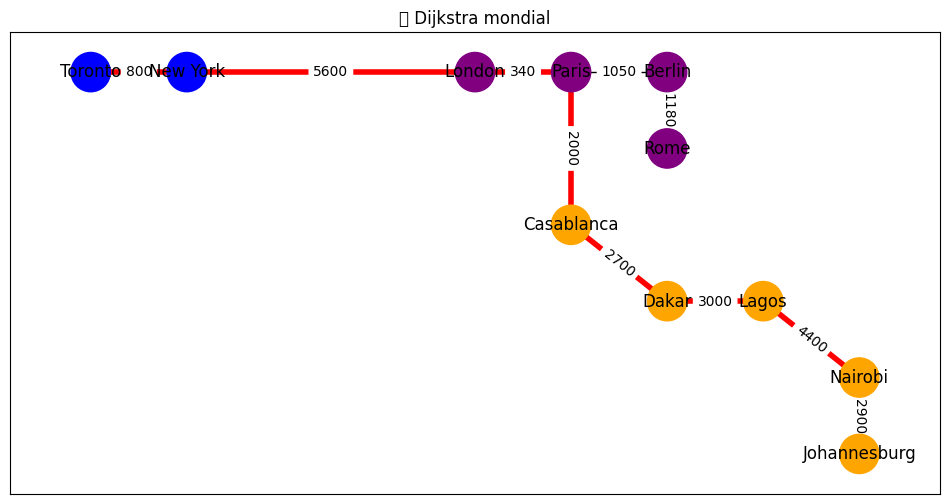

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import os

# créer dossier images
os.makedirs("images", exist_ok=True)

G = nx.Graph()

edges = [
    ('Toronto','New York',800),
    ('New York','London',5600),
    ('London','Paris',340),
    ('Paris','Berlin',1050),
    ('Berlin','Rome',1180),
    ('Paris','Casablanca',2000),
    ('Casablanca','Dakar',2700),
    ('Dakar','Lagos',3000),
    ('Lagos','Nairobi',4400),
    ('Nairobi','Johannesburg',2900),
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

pos = {
    'Toronto':(-5,2),'New York':(-4,2),
    'London':(-1,2),'Paris':(0,2),'Berlin':(1,2),'Rome':(1,1),
    'Casablanca':(0,0),'Dakar':(1,-1),'Lagos':(2,-1),
    'Nairobi':(3,-2),'Johannesburg':(3,-3),
}

colors = {
    'Toronto':'blue','New York':'blue',
    'London':'purple','Paris':'purple','Berlin':'purple','Rome':'purple',
    'Casablanca':'orange','Dakar':'orange','Lagos':'orange','Nairobi':'orange','Johannesburg':'orange'
}

node_colors = [colors[n] for n in G.nodes()]

path = nx.shortest_path(G, 'Toronto', 'Johannesburg', weight='weight')

plt.figure(figsize=(12,6))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)

# chemin en rouge
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(zip(path, path[1:])),
    width=4,
    edge_color='red'
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'weight'))

plt.title("🌍 Dijkstra mondial")
plt.savefig("images/graphe.png")
plt.show()